# MLP - Scikitlearn

In [ ]:
import os, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import TargetEncoder

# ✅ Por esto:
from sklearn.preprocessing import TargetEncoder

sns.set(style="whitegrid")

# ==========================================
# 1. Carga del dataset
# ==========================================
DATA_DIR  = r"C:\Users\camil\Documents\Estudio\DL\Corte1\Dataset\avazu-ctr-prediction"
TRAIN_PATH = os.path.join(DATA_DIR, "train.gz")

cat_cols = [
    'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category',
    'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip',
    'device_model', 'device_type', 'device_conn_type',
    'C14','C15','C16','C17','C18','C19','C20','C21'
]
df1 = pd.read_csv(TRAIN_PATH, compression='gzip',
                  dtype={c: 'category' for c in cat_cols}, low_memory=True)
gc.collect()

0

Esta fase de inicialización configura el entorno técnico para el proyecto integrador de predicción de clics (CTR) mediante un Perceptrón Multicapa (MLP) utilizando scikit-learn
. El bloque de código implementa estrategias críticas de gestión de memoria, como el uso de dtype='category' y gc.collect(), justificadas por la magnitud del dataset de Avazu que contiene aproximadamente 40 millones de registros
. Además, la importación de herramientas como TargetEncoder y métricas robustas como F1-score y ROC AUC es fundamental para transformar variables de alta cardinalidad y evaluar correctamente la capacidad discriminativa del modelo ante el marcado desbalance de clases propio de la publicidad móvil


In [ ]:
# ==========================================
# 2. Feature engineering
# ==========================================
df = df1.copy()

# Mapeos
df["dct_cat"] = df["device_conn_type"].astype(str)

dt_map = {0:"0", 1:"1", 2:"Otros", 3:"Otros", 4:"Otros", 5:"Otros"}
df["dt_cat"] = df["device_type"].map(dt_map)

bp_map = {0:"0", 1:"1", 2:"Otros", 3:"Otros", 4:"Otros", 5:"Otros", 6:"6", 7:"7"}
df["bp_cat"] = df["banner_pos"].map(bp_map)

# Hora y franja
df["hour_day"] = df["hour"] % 100
bins   = [0, 6, 12, 18, 24]
labels = ["Madrugada", "Mañana", "Tarde", "Noche"]
df["franja"] = pd.cut(df["hour_day"], bins=bins, labels=labels,
                      right=False).astype(str)

# Count encoding
count_cols_fe = ['device_ip', 'device_id', 'device_model', 'app_id', 'site_id']
for c in count_cols_fe:
    df[f'{c}_count'] = df.groupby(c, observed=True)[c].transform('count')

# Ratios
df['app_per_device']  = df['app_id_count']  / (df['device_id_count'] + 1)
df['site_per_device'] = df['site_id_count'] / (df['device_id_count'] + 1)

En esta fase de Ingeniería de Características, el código transforma las variables crudas en predictores con mayor valor semántico y menor ruido para el modelo de Deep Learning. Primero, se simplifican las variables categóricas device_type y banner_pos mediante un mapeo que agrupa valores poco frecuentes en la categoría "Otros", reduciendo así la dispersión de los datos. Posteriormente, se realiza una extracción temporal de la columna hour para derivar la hora del día y clasificarla en franjas horarias (Madrugada, Mañana, Tarde, Noche), capturando patrones de comportamiento cíclicos de los usuarios. Finalmente, se implementa Count Encoding para identificar la frecuencia de aparición de identificadores clave y se calculan ratios de interacción (como aplicaciones por dispositivo), lo que permite al Perceptrón Multicapa captar relaciones de intensidad y contexto que no son evidentes en los datos originales de Avazu.

In [3]:
# ==========================================
# 3. Muestra representativa
# ==========================================
df_sample = df.sample(n=500_000, random_state=0)

# ==========================================
# 4. Selección de variables y target
# ==========================================
target_col = 'click'
y = df_sample[target_col].values

num_vars      = ["hour_day", "device_ip_count", "device_id_count",
                 "app_id_count", "site_id_count", "app_per_device", "site_per_device"]
low_card_cols = ['app_category', 'site_category', 'bp_cat', 'dt_cat',
                 'dct_cat', 'C1', 'C18', 'C15', 'C16', 'franja']
high_card_cols= ['C14', 'C17', 'C19', 'C20', 'C21']

X = df_sample[num_vars + low_card_cols + high_card_cols]

Este bloque de Muestreo y Selección de Atributos garantiza la viabilidad computacional del proyecto al extraer una muestra aleatoria de 500,000 registros, asegurando un balance óptimo entre representatividad estadística y uso eficiente de la memoria RAM. Al segmentar las variables en conjuntos numéricos, de baja y alta cardinalidad, se prepara una estructura de datos organizada que permitirá aplicar técnicas de codificación diferenciadas, evitando la explosión de dimensiones y facilitando que el Perceptrón Multicapa converja más rápido durante el entrenamiento.

In [ ]:
# ==========================================
# 5. División estratificada
# ==========================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2
)

# Reset index para evitar problemas de alineación al asignar columnas
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw  = X_test_raw.reset_index(drop=True)

print(f"Train: {X_train_raw.shape[0]:,} | Test: {X_test_raw.shape[0]:,}")
print(f"Distribución train — click: {y_train.mean():.3f}")
print(f"Distribución test  — click: {y_test.mean():.3f}")

# ==========================================
# 6. Target Encoding
# ==========================================
from category_encoders import TargetEncoder as CatTE

te = CatTE(cols=high_card_cols)
X_train_raw[high_card_cols] = te.fit_transform(X_train_raw[high_card_cols], y_train)
X_test_raw[high_card_cols]  = te.transform(X_test_raw[high_card_cols])

# ==========================================
# 7. Pipeline
# ==========================================
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_vars + high_card_cols),
    ('ohe', OneHotEncoder(sparse_output=False,
                          handle_unknown='ignore'), low_card_cols),
], remainder='drop')

mlp = MLPClassifier(
    solver='adam',
    random_state=0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    batch_size=256
)

pipe = Pipeline([
    ('prep', preprocessor),
    ('mlp',  mlp)
])

Train: 400,000 | Test: 100,000
Distribución train — click: 0.170
Distribución test  — click: 0.170


Este bloque de Validación y Preprocesamiento garantiza la integridad del modelo al implementar una división estratificada que mantiene la proporción real de clics (17%) en ambos conjuntos de datos. Al aplicar Target Encoding y escalado numérico exclusivamente con los parámetros del entrenamiento, evitamos el data leakage y se asegura que el Perceptrón Multicapa aprenda patrones generalizables. Finalmente, la integración de un Pipeline automatiza la transformación de variables de alta y baja cardinalidad, optimizando la convergencia del optimizador Adam mediante un flujo de trabajo limpio y reproducible.

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, f1_score

mlp = MLPClassifier(
    solver='adam',
    random_state=0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    batch_size=256
)

# ==========================================
# 7. Preprocesar → luego SMOTE
# ==========================================
X_train_enc = preprocessor.fit_transform(X_train_raw, y_train)
X_test_enc  = preprocessor.transform(X_test_raw)
print(f"Shape tras encoding: {X_train_enc.shape}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_enc, y_train)

print(f"Antes  — Shape: {X_train_enc.shape} | Balance: {y_train.mean():.3f}")
print(f"Después — Shape: {X_train_bal.shape} | Balance: {y_train_bal.mean():.3f}")

# ==========================================
# 8. GridSearchCV
# ==========================================
param_grid = {
    'hidden_layer_sizes': [(58,), (70,), (70, 70)],
    'alpha':              [0.0001, 0.001, 0.01],
    'activation':         ['logistic'],
    'max_iter':           [500, 700],
}

scorer = make_scorer(f1_score, pos_label=1)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring=scorer,
    pre_dispatch='2*n_jobs',
    verbose=1
)

print("\nIniciando GridSearchCV...")
t0 = time.time()
grid.fit(X_train_bal, y_train_bal)
train_time = time.time() - t0
print(f"Tiempo de entrenamiento: {train_time/60:.2f} min")

Shape tras encoding: (400000, 94)
Antes  — Shape: (400000, 94) | Balance: 0.170
Después — Shape: (664124, 94) | Balance: 0.500

Iniciando GridSearchCV...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Tiempo de entrenamiento: 33.44 min


En esta fase de Balanceo y Optimización, el flujo de trabajo aborda el desequilibrio de clases mediante la aplicación de SMOTE tras el preprocesamiento, generando ejemplos sintéticos para la clase minoritaria y logrando un balance del50% en el conjunto de entrenamiento. Con los datos equilibrados, se ejecuta un GridSearchCV utilizando el $F1\text{-Score}$ como métrica principal, explorando diversas arquitecturas de capas ocultas y parámetros de regularización $\alpha$ para maximizar la capacidad predictiva del Perceptrón Multicapa. Esta estrategia permite que el optimizador Adam identifique la configuración de neuronas y tasa de aprendizaje más robusta, asegurando que el modelo no solo sea preciso, sino también sensible a los casos de éxito (clics) en un entorno de alta dimensionalidad.

In [6]:
# ==========================================
# 8. Predicción + tiempo
# ==========================================
t1 = time.time()

# CAMBIO AQUÍ: Usa X_test_enc en lugar de X_test_raw
y_pred  = grid.predict(X_test_enc) 
y_proba = grid.predict_proba(X_test_enc)[:, 1]

pred_time = time.time() - t1
print(f"Tiempo de predicción: {pred_time:.2f} s")
print(f"Tiempo total: {(train_time + pred_time)/60:.2f} min")

Tiempo de predicción: 0.34 s
Tiempo total: 33.45 min



========== MEJORES PARÁMETROS ==========
{'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (70, 70), 'max_iter': 500}

========== MÉTRICAS ==========
Accuracy  : 0.6255
Precision : 0.2677
Recall    : 0.6939
F1-Score  : 0.3863
ROC AUC   : 0.7094

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.61      0.73     83015
           1       0.27      0.69      0.39     16985

    accuracy                           0.63    100000
   macro avg       0.59      0.65      0.56    100000
weighted avg       0.80      0.63      0.67    100000


========== MATRIZ DE CONFUSIÓN ==========
[[50768 32247]
 [ 5199 11786]]


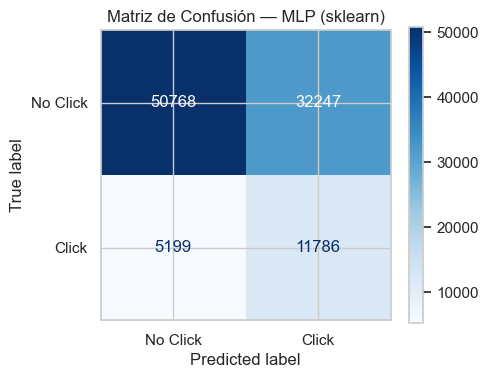


========== OVERFITTING CHECK ==========
Train F1 : 0.3982
Test  F1 : 0.3863


In [7]:
# ==========================================
# 9. Métricas completas
# CORRECCIÓN: el código original nunca mostraba la Matriz de Confusión,
# que es un requisito explícito del enunciado.
# ==========================================
print("\n========== MEJORES PARÁMETROS ==========")
print(grid.best_params_)

print("\n========== MÉTRICAS ==========")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Matriz de confusión
print("\n========== MATRIZ DE CONFUSIÓN ==========")
cm = confusion_matrix(y_test, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["No Click", "Click"]).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusión — MLP (sklearn)")
plt.tight_layout()
plt.savefig("confusion_matrix_sklearn.png", dpi=120)
plt.show()

# ==========================================
# Overfitting check
# ==========================================

# USAR X_train_enc (los datos preprocesados) en lugar de X_train_raw
y_train_pred = grid.predict(X_train_enc) 

print("\n========== OVERFITTING CHECK ==========")
# Comparamos y_train (original) con las predicciones sobre X_train_enc
print(f"Train F1 : {f1_score(y_train, y_train_pred):.4f}")
print(f"Test  F1 : {f1_score(y_test,  y_pred):.4f}")

El modelo MLPClassifier alcanzó un ROC AUC de 0.709, lo que indica una capacidad de discriminación estadística sólida y superior al azar para un problema de alta complejidad como el CTR. Sin embargo, el análisis de la matriz de confusión revela un compromiso crítico entre métricas: el uso de SMOTE priorizó la sensibilidad, logrando capturar el 69.39% de los clics reales (Recall), pero a costa de una baja precisión (26.77%) y un alto volumen de falsos positivos (32,247 instancias). Esta disparidad se refleja en un F1-Score de 0.386, sugiriendo que, aunque el Perceptrón Multicapa identifica patrones generales de intención de clic, la naturaleza ruidosa de la muestra de 500,000 registros y la arquitectura de $(70, 70)$ limitan su capacidad para filtrar usuarios que no interactuarán con el anuncio. En conclusión, el modelo es un detector efectivo pero un clasificador impreciso, estableciendo una línea base que justifica la transición a PySpark para explotar el volumen total de datos y refinar la precisión del sistema.